In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [3]:
df = pd.read_csv("mushroom_classification.csv")

In [4]:
df.head()

,cap_diameter,cap_shape,gill_attachment,gill_color,stem_height,stem_width,stem_color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


In [5]:
df.isnull().sum()

cap_diameter       0
cap_shape          0
gill_attachment    0
gill_color         0
stem_height        0
stem_width         0
stem_color         0
season             0
class              0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54035 entries, 0 to 54034
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cap_diameter     54035 non-null  int64  
 1   cap_shape        54035 non-null  int64  
 2   gill_attachment  54035 non-null  int64  
 3   gill_color       54035 non-null  int64  
 4   stem_height      54035 non-null  float64
 5   stem_width       54035 non-null  int64  
 6   stem_color       54035 non-null  int64  
 7   season           54035 non-null  float64
 8   class            54035 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.7 MB


In [8]:
cat_cols = ["cap_shape", "gill_attachment", "gill_color","stem_color", "season", "class"]

In [9]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
df.head()

,cap_diameter,cap_shape,gill_attachment,gill_color,stem_height,stem_width,stem_color,season,class
0,1372,2,2,10,3.807467,1545,11,3,1
1,1461,2,2,10,3.807467,1557,11,3,1
2,1371,2,2,10,3.612496,1566,11,3,1
3,1261,6,2,10,3.787572,1566,11,3,1
4,1305,6,2,10,3.711971,1464,11,2,1


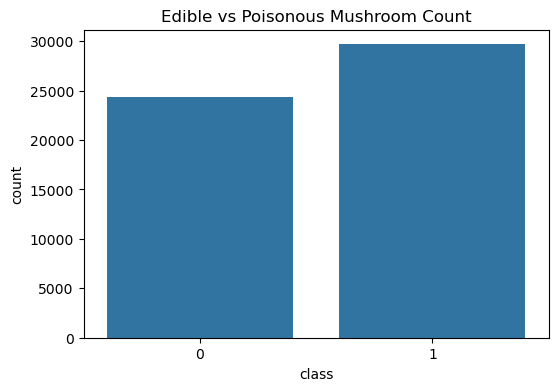

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=df)
plt.title("Edible vs Poisonous Mushroom Count")
plt.show()

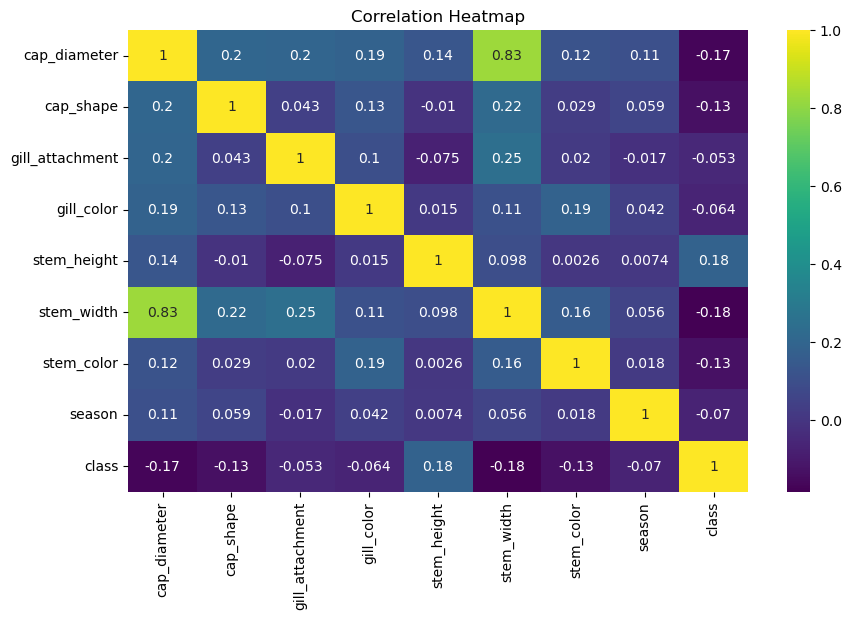

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

GaussianNB()

In [17]:
y_pred = nb.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6470805959100583

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.63      0.61      4872
           1       0.68      0.67      0.67      5935

    accuracy                           0.65     10807
   macro avg       0.64      0.65      0.64     10807
weighted avg       0.65      0.65      0.65     10807


Confusion Matrix:
 [[3046 1826]
 [1988 3947]]


In [18]:
joblib.dump(nb, "mushroom_nb.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']